# freezing 11/9/23

In [1]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *

import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product



%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [2]:
pre=100
post=100
session_path = '../data/co6/co6_10122023'
session = MPOptoClass(session_path, post=post)

love


# co6, 10/12/23

# 0. smoothing for better r^2

In [3]:
num_PCs = 20
#(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=session.climbing_bounds, binsize=10, nlags=10, num_PCs=0)
#all_cut_CFAPCA = all_cut_PCA[:, :session.num_CFA]

laser_bounds = copy.deepcopy(session.laser['laser_bounds'])
laser_bounds[:,0] = laser_bounds[:,0] - pre
train_lasers, test_lasers = train_test_split(laser_bounds, train_size=0.8)

omitTestLaserBounds = omitBoundInBounds(session.climbing_bounds, test_lasers)
omitAllLaserBounds = omitBoundInBounds(session.climbing_bounds, laser_bounds)

#(all_nlags_PCA, all_cut_PCA), all_PCObjs = session.format_nlags_PCA(bounds=omitAllLaserBounds, binsize=5, nlags=20, num_PCs=num_PCs)


(all_nlags_PCA, no_smooth), nada = session.format_nlags_PCA(bounds=omitAllLaserBounds, binsize=10, nlags=10, num_PCs=num_PCs)
(sall_nlags_PCA, causal_smooth), all_PCObjs = session.format_nlags_PCA_smooth(bounds=omitAllLaserBounds, sigma=30, binsize=10, nlags=10, num_PCs=num_PCs, smooth_type='causal')
(nada, sall_cut_PCA), nada = session.format_nlags_PCA_smooth(bounds=omitAllLaserBounds, sigma=30, binsize=10, nlags=10, num_PCs=num_PCs, smooth_type='future')

sall_cut_CFAPCA = sall_cut_PCA[:, :num_PCs]

(slaser_nlags_PCA, nada), laser_PCObjs = session.format_nlags_PCA_smooth(bounds=omitTestLaserBounds, sigma=30, binsize=10, nlags=10, num_PCs=num_PCs, smooth_type='causal')
(nada, slaser_cut_PCA), nada = session.format_nlags_PCA_smooth(bounds=omitTestLaserBounds, sigma=30, binsize=10, nlags=10, num_PCs=num_PCs, smooth_type='future')

slaser_cut_CFAPCA = slaser_cut_PCA[:, :num_PCs]


In [4]:
print(sall_nlags_PCA.shape)
print(sall_cut_PCA.shape)

(35819, 400)
(35819, 40)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


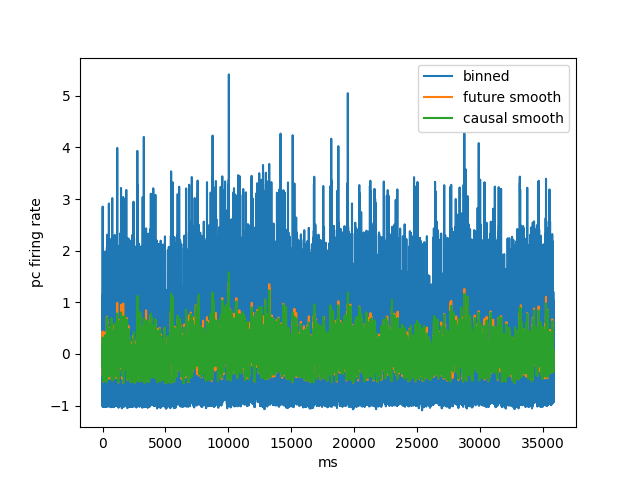

In [5]:
fig0, ax0 = plt.subplots()
ax0.plot(no_smooth[:,0], label='binned')
ax0.plot(sall_cut_PCA[:,0], label='future smooth')
ax0.plot(causal_smooth[:,0], label='causal smooth')
ax0.set_xlabel('ms')
ax0.set_ylabel('pc firing rate')
ax0.legend()

In [6]:
all_output = Ridge_kfolds_redo(sall_nlags_PCA, sall_cut_CFAPCA, alpha=2000, k=10)
laser_output = Ridge_kfolds_redo(slaser_nlags_PCA, slaser_cut_CFAPCA, alpha=2000, k=10)
binned_output = Ridge_kfolds_redo(all_nlags_PCA, no_smooth[:,:num_PCs], alpha=2000, k=10)

10it [00:01,  5.28it/s]
10it [00:01,  5.19it/s]
10it [00:01,  5.43it/s]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


climbing fit score: 0.45803437059588037
climbing test score: 0.44179349660882594
with stim fit score: 0.46059861838682803
with stim test score: 0.44502586265698


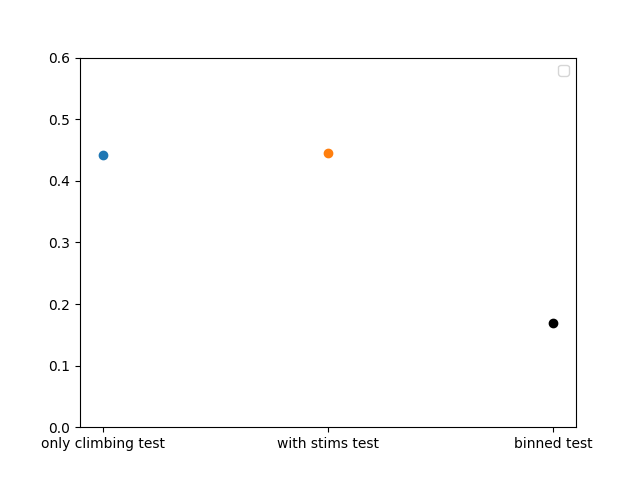

In [7]:
fitscore = all_output['fit_score']
testscore = all_output['test_score']
print(f'climbing fit score: {fitscore}')
print(f'climbing test score: {testscore}')
fig01, ax01 = plt.subplots()

stim_fitscore = laser_output['fit_score']
stim_testscore = laser_output['test_score']

binned_score = binned_output['test_score']
print(f'with stim fit score: {stim_fitscore}')
print(f'with stim test score: {stim_testscore}')
#ax01.scatter(['only climbing fit'], fitscore, color='tab:blue', label='trained on only climbing')
#ax01.scatter(['with stims fit'], stim_fitscore, color='tab:orange', label='trained with stims')
ax01.scatter(['only climbing test'], testscore, color='tab:blue')
ax01.scatter(['with stims test'], stim_testscore, color='tab:orange')
ax01.scatter(['binned test'], binned_score, color='black')
ax01.set_ylim([0,.6])
ax01.legend()



0.41741442866378264


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


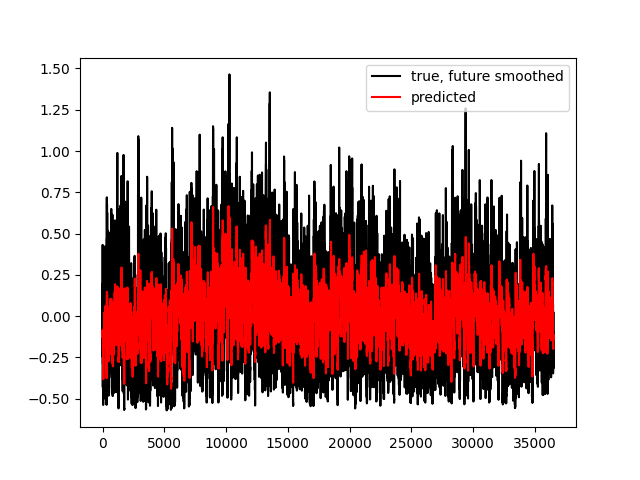

In [8]:
laser_model = laser_output['best_model']
predic = laser_model.predict(slaser_nlags_PCA)
fig1, ax1 = plt.subplots()
ax1.plot(slaser_cut_CFAPCA[:, 0], color='black', label='true, future smoothed')
ax1.plot(predic[:,0], color='red', label='predicted')
ax1.legend()
print(r2_score(slaser_cut_CFAPCA[:,0], predic[:,0]))

0.3579613396100644


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


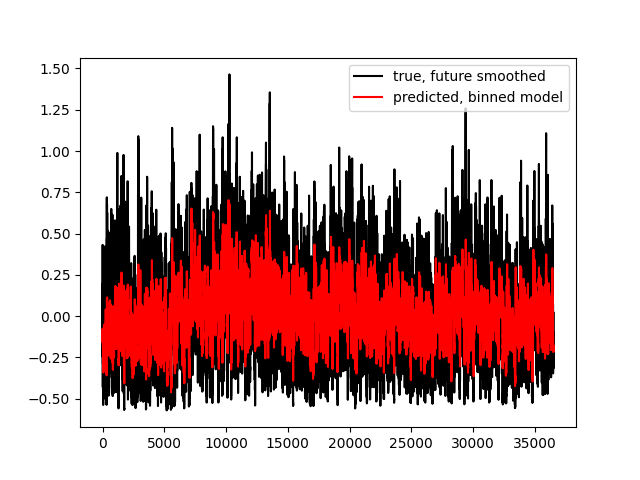

In [9]:
binned_model = binned_output['best_model']
predic = binned_model.predict(slaser_nlags_PCA)
fig11, ax11 = plt.subplots()
ax11.plot(slaser_cut_CFAPCA[:, 0], color='black', label='true, future smoothed')
ax11.plot(predic[:,0], color='red', label='predicted, binned model')
ax11.legend()
print(r2_score(slaser_cut_CFAPCA[:,0], predic[:,0]))


# repeating with different # lags

In [11]:
num_PCs = 20
#(all_nlags_PCA, all_cut_PCA), (CFA_PCObj, RFA_PCObj) = session.format_nlags_PCA(bounds=session.climbing_bounds, binsize=10, nlags=10, num_PCs=0)
#all_cut_CFAPCA = all_cut_PCA[:, :session.num_CFA]

laser_bounds = copy.deepcopy(session.laser['laser_bounds'])
laser_bounds[:,0] = laser_bounds[:,0] - pre
train_lasers, test_lasers = train_test_split(laser_bounds, train_size=0.8)

omitTestLaserBounds = omitBoundInBounds(session.climbing_bounds, test_lasers)
omitAllLaserBounds = omitBoundInBounds(session.climbing_bounds, laser_bounds)

#(all_nlags_PCA, all_cut_PCA), all_PCObjs = session.format_nlags_PCA(bounds=omitAllLaserBounds, binsize=5, nlags=20, num_PCs=num_PCs)


(all_nlags_PCA, no_smooth), nada = session.format_nlags_PCA(bounds=omitAllLaserBounds, binsize=10, nlags=3, num_PCs=num_PCs)
(sall_nlags_PCA, causal_smooth), nada = session.format_nlags_PCA_smooth(bounds=omitAllLaserBounds, sigma=30, binsize=10, nlags=3, num_PCs=num_PCs, smooth_type='causal')
(nada, sall_cut_PCA), nada = session.format_nlags_PCA_smooth(bounds=omitAllLaserBounds, sigma=30, binsize=10, nlags=3, num_PCs=num_PCs, smooth_type='future')

sall_cut_CFAPCA = sall_cut_PCA[:, :num_PCs]

(slaser_nlags_PCA, nada), nada = session.format_nlags_PCA_smooth(bounds=omitTestLaserBounds, sigma=30, binsize=10, nlags=3, num_PCs=num_PCs, smooth_type='causal')
(nada, slaser_cut_PCA), nada = session.format_nlags_PCA_smooth(bounds=omitTestLaserBounds, sigma=30, binsize=10, nlags=3, num_PCs=num_PCs, smooth_type='future')

slaser_cut_CFAPCA = slaser_cut_PCA[:, :num_PCs]


all_output = Ridge_kfolds_redo(sall_nlags_PCA, sall_cut_CFAPCA, alpha=2000, k=10)
laser_output = Ridge_kfolds_redo(slaser_nlags_PCA, slaser_cut_CFAPCA, alpha=2000, k=10)

10it [00:00, 19.09it/s]
10it [00:00, 20.26it/s]


climbing fit score: 0.4093964497459651
climbing test score: 0.39521319694364254
with stim fit score: 0.4093964497459651
with stim test score: 0.39521319694364254


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


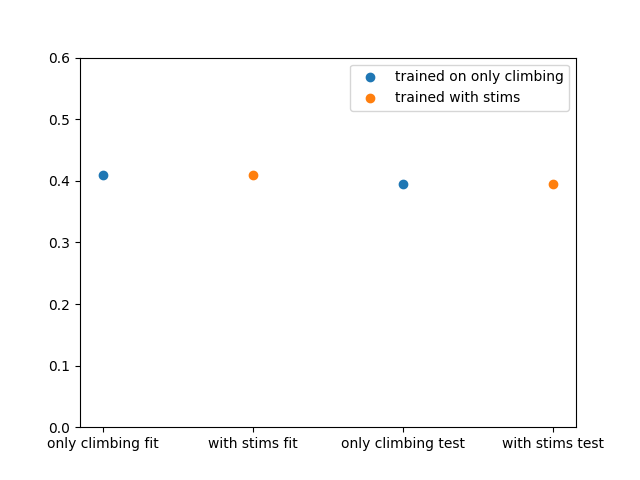

In [12]:
fitscore = all_output['fit_score']
testscore = all_output['test_score']
print(f'climbing fit score: {fitscore}')
print(f'climbing test score: {testscore}')
fig1, ax1 = plt.subplots()

stim_fitscore = laser_output['fit_score']
stim_testscore = laser_output['test_score']
print(f'with stim fit score: {fitscore}')
print(f'with stim test score: {testscore}')
ax1.scatter(['only climbing fit'], fitscore, color='tab:blue', label='trained on only climbing')
ax1.scatter(['with stims fit'], fitscore, color='tab:orange', label='trained with stims')
ax1.scatter(['only climbing test'], testscore, color='tab:blue')
ax1.scatter(['with stims test'], testscore, color='tab:orange')
ax1.set_ylim([0,.6])
ax1.legend()



# load sweep

In [47]:
output = pload('/home/diya/Documents/mp_opto/picklejar/sweepRegs.pickle')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


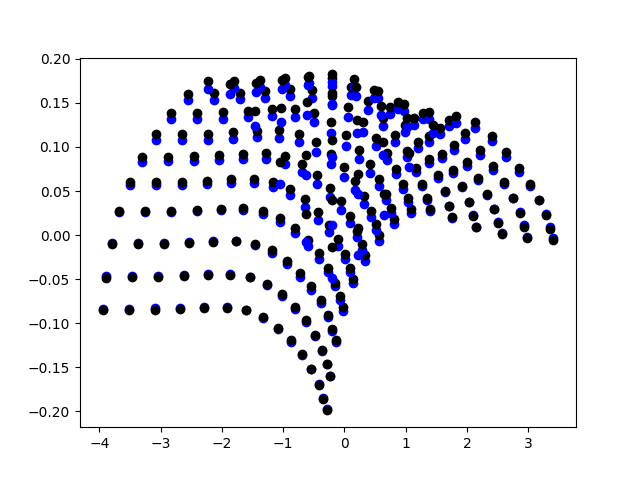

In [48]:
fig, ax = plt.subplots()
ratio_list = []
h_list = []
laser_score_list = []
ctrl_score_list = []
for idx, o in enumerate(output):
    h = o[0]
    laser_score = o[1]
    ctrl_score = o[2]
    
    temp = session.weights_per_region(h)
    ratio = np.log10(temp[0]/temp[1])
    
    ratio_list.append(ratio)
    h_list.append(h)
    laser_score_list.append(laser_score)
    ctrl_score_list.append(ctrl_score)
    
    ax.scatter(ratio, o[1], color='blue')
    ax.scatter(ratio, o[2], color='black')
#ax.legend()

In [49]:
reg_terms = np.logspace(0,6,15)
reg_combos = list(product(reg_terms, reg_terms))
laser_score_list = np.array(laser_score_list)
ctrl_score_list = np.array(ctrl_score_list)
ratio_list = np.array(ratio_list)

In [50]:
nada, bin_ratio_edges = np.histogram(ratio_list, bins=15)

laser_score_keep = []
ctrl_score_keep = []
ratio_keep = []

for i in range(bin_ratio_edges.size - 1):
    condition1 = ratio_list > bin_ratio_edges[i]
    condition2 = ratio_list < bin_ratio_edges[i+1]
    indices = np.argwhere(np.logical_and(condition1,condition2))
    keep = np.argmax(laser_score_list[indices])
    temp1 = laser_score_list[indices]
    temp2 = temp1[keep]
    laser_score_keep.append(temp2)
    
    temp1 = ratio_list[indices]
    temp2 = temp1[keep]
    ratio_keep.append(temp2)
    
    indices = np.argwhere(np.logical_and(condition1,condition2))
    keep = np.argmax(ctrl_score_list[indices])
    temp1 = ctrl_score_list[indices]
    temp2 = temp1[keep]
    ctrl_score_keep.append(temp2) 
    

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


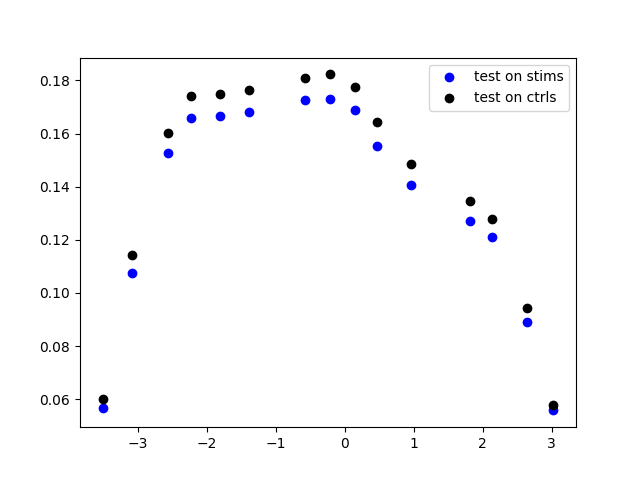

In [53]:
fig, ax = plt.subplots()
ax.scatter(ratio_keep, laser_score_keep, color='blue', label='test on stims')
ax.scatter(ratio_keep, ctrl_score_keep, color='black', label='test on ctrls')
ax.legend()